# **Phase** **2**
**Data** **Summarization** **and** **Preprocessing**

## **1**. **Data** **Understanding** **and** **Statistical** **Summary**

## 1.1 Data Understanding

In this section, we examine the structure and characteristics of the raw dataset before applying any preprocessing techniques.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [24]:
df = pd.read_csv("Raw_Dataset.csv")

In [25]:

display(df.head())
df.shape
df.columns
df.info()

,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,NaN,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,NaN,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      3000 non-null   object 
 1   Age                          3000 non-null   int64  
 2   Gender                       3000 non-null   object 
 3   Exercise Level               3000 non-null   object 
 4   Diet Type                    3000 non-null   object 
 5   Sleep Hours                  3000 non-null   float64
 6   Stress Level                 3000 non-null   object 
 7   Mental Health Condition      2405 non-null   object 
 8   Work Hours per Week          3000 non-null   int64  
 9   Screen Time per Day (Hours)  3000 non-null   float64
 10  Social Interaction Score     3000 non-null   float64
 11  Happiness Score              3000 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 281.4+ KB



 The dataset consists of 3000 rows and 12 columns, featuring a combination of numerical and categorical attributes. Categorical attributes include Country, Gender, Exercise Level, Diet Type, Stress Level, and Mental Health Condition, while numerical attributes comprise Age, Sleep Hours, Work Hours per Week, Screen Time per Day, Social Interaction Score, and Happiness Score. Most columns contain complete data with 3000 non-null entries, except for "Mental Health Condition", which has 2405 non-null values, indicating 595 missing values. Consequently, data preprocessing will be necessary to handle these missing entries prior to building machine learning models.
>


##1.2 Statistical Summary (Five Number Summary)

In [26]:
df.describe()

,Age,Sleep Hours,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,41.229667,6.475933,39.466333,5.089833,5.470200,5.395067
std,13.428416,1.499866,11.451459,1.747231,2.563532,2.557601
min,18.000000,1.400000,20.000000,2.000000,1.000000,1.000000
25%,30.000000,5.500000,30.000000,3.600000,3.300000,3.200000
50%,41.000000,6.500000,39.000000,5.100000,5.500000,5.400000
75%,53.000000,7.500000,50.000000,6.600000,7.600000,7.500000
max,64.000000,11.300000,59.000000,8.000000,10.000000,10.000000



The statistical summary provides descriptive statistics for the dataset. The average age is about 41 years (ranging from 18 to 64), average sleep is 6.48 hours (1.4 to 11.3), average work hours is 39.47 per week (20 to 59), and average daily screen time is 5.09 hours (2 to 8). Additionally, Social Interaction and Happiness scores average around 5.47 and 5.39, respectively, with ranges from 1 to 10. Overall, the numerical attributes show a reasonable spread. Potential outliers are examined further using the IQR method and boxplots in the following section.
>


In [27]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    print("Five-number summary for", col)
    print(df[col].describe()[['min', '25%', '50%', '75%', 'max']])
    print("-" * 30)
    print()


Five-number summary for Age
min    18.0
25%    30.0
50%    41.0
75%    53.0
max    64.0
Name: Age, dtype: float64
------------------------------

Five-number summary for Sleep Hours
min     1.4
25%     5.5
50%     6.5
75%     7.5
max    11.3
Name: Sleep Hours, dtype: float64
------------------------------

Five-number summary for Work Hours per Week
min    20.0
25%    30.0
50%    39.0
75%    50.0
max    59.0
Name: Work Hours per Week, dtype: float64
------------------------------

Five-number summary for Screen Time per Day (Hours)
min    2.0
25%    3.6
50%    5.1
75%    6.6
max    8.0
Name: Screen Time per Day (Hours), dtype: float64
------------------------------

Five-number summary for Social Interaction Score
min     1.0
25%     3.3
50%     5.5
75%     7.6
max    10.0
Name: Social Interaction Score, dtype: float64
------------------------------

Five-number summary for Happiness Score
min     1.0
25%     3.2
50%     5.4
75%     7.5
max    10.0
Name: Happiness Score, dtype: float64


 The five-number summary highlights the distribution of numerical attributes in the dataset. Age ranges from 18 to 64 (median 41), Sleep Hours from 1.4 to 11.3 (median 6.5), and Work Hours from 20 to 59 per week (median 39). Daily screen time ranges from 2 to 8 hours (median 5.1). Both Social Interaction and Happiness scores range from 1 to 10, with medians of 5.5 and 5.4, respectively. Overall, the numerical attributes show a reasonable spread, while potential outliers are examined further in the following section.
>


# **2**. **Missing** **Values** **Analysis** **and** **Outlier** **Detection**

## 2.1 Missing Values Analysis

Missing values are values that are not available or not recorded for some observations. Identifying missing values is an important step before applying data preprocessing techniques.

In [28]:
missing_analysis = pd.DataFrame({
    "Missing Values": df.isnull().sum()
})
display(missing_analysis)


,Missing Values
Country,0
Age,0
Gender,0
Exercise Level,0
Diet Type,0
Sleep Hours,0
Stress Level,0
Mental Health Condition,595
Work Hours per Week,0
Screen Time per Day (Hours),0


#### Missing Values Findings

Most attributes do not have missing values. However, 'Mental Health Condition' contains 595 missing values. Because this is a significant portion, imputation is required during the preprocessing stage to avoid losing records."

## 2.2 Outlier Detection

Outliers are observations that are unusually distant from the majority of the data. The Interquartile Range (IQR) method is used to identify potential outliers in the numerical attributes.

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Values below the lower bound or above the upper bound are considered potential outliers.

In [29]:
numeric_columns = df.select_dtypes(include=np.number).columns

outlier_summary = []

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    outlier_summary.append({
        "Attribute": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Outliers": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Attribute,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers
0,Age,30.0,53.0,23.0,-4.50,87.50,0
1,Sleep Hours,5.5,7.5,2.0,2.50,10.50,16
2,Work Hours per Week,30.0,50.0,20.0,0.00,80.00,0
3,Screen Time per Day (Hours),3.6,6.6,3.0,-0.90,11.10,0
4,Social Interaction Score,3.3,7.6,4.3,-3.15,14.05,0
5,Happiness Score,3.2,7.5,4.3,-3.25,13.95,0


#### Outlier

The IQR method identified 16 potential outliers in "Sleep Hours". The other numerical attributes did not have any potential outliers using this method.

For "Sleep Hours", Q1 is 5.5 and Q3 is 7.5, giving an IQR of 2. The lower bound is 2.5 and the upper bound is 10.5. Therefore, values below 2.5 or above 10.5 were identified as potential outliers.


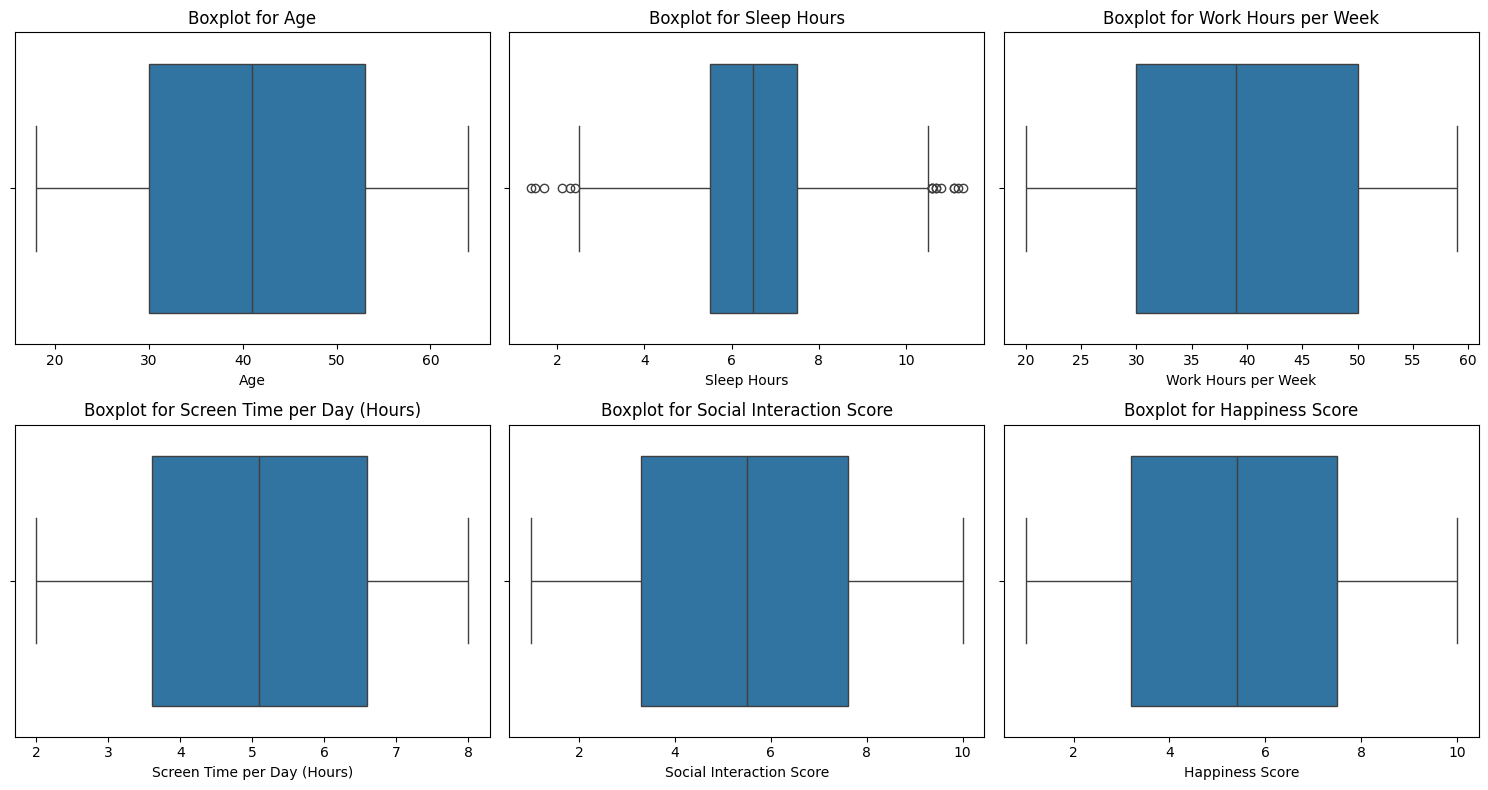

In [30]:
numeric_columns = [
    'Age',
    'Sleep Hours',
    'Work Hours per Week',
    'Screen Time per Day (Hours)',
    'Social Interaction Score',
    'Happiness Score'
]

plt.figure(figsize=(15, 8))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot for {column}')

plt.tight_layout()
plt.show()

#### Boxplot

The boxplots show the distribution and spread of the numerical attributes. The "Sleep Hours" boxplot shows potential outlying values, which agrees with the IQR results. The other numerical attributes do not show potential outliers according to the IQR method. This indicates that Sleep Hours requires further preprocessing to handle the potential outliers before applying data mining techniques.

# **3**. **Data** **Visualization** **and** **Class** **Label** **Distribution**


##3.1 Class Label Distribution
The class label in this dataset is "Stress Level", which consists of three classes: Low, Moderate, and High. The following bar plot shows the distribution of these classes in the dataset.

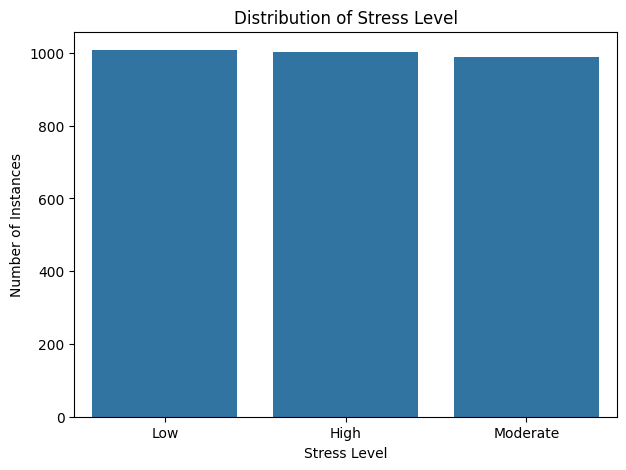

In [31]:
stress_counts = df['Stress Level'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=stress_counts.index, y=stress_counts.values)

plt.title('Distribution of Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Number of Instances')
plt.show()

Class Label Distribution Findings

The bar plot shows that the three Stress Level classes are nearly balanced. Low has 1008 instances, High has 1002 instances, and Moderate has 990 instances. This indicates that class imbalance is not a major issue that needs to be addressed during preprocessing.

## 3.2 Variable Distribution

A histogram is used to examine the distribution of Sleep Hours, which is one of the numerical attributes in the dataset.

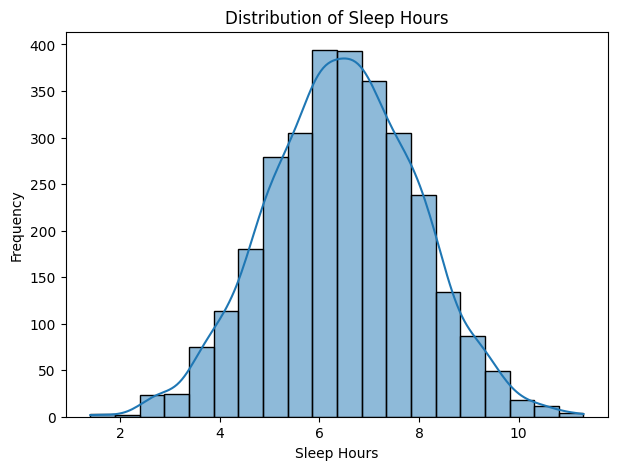

In [32]:
plt.figure(figsize=(7, 5))
sns.histplot(df['Sleep Hours'], bins=20, kde=True)

plt.title('Distribution of Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('Frequency')
plt.show()

Histogram Findings

The histogram shows that Sleep Hours are approximately normally distributed, with most observations concentrated around 6 to 7 hours. Only a small number of observations appear at the lower and upper ends of the distribution. This supports the previous outlier analysis, which identified a small number of potential outliers in Sleep Hours. Therefore, Sleep Hours requires further preprocessing to handle the potential outliers.

## 3.3 Relationship Between Numerical Attributes

A scatter plot is used to examine the relationship between Sleep Hours and Happiness Score across the different Stress Level classes.

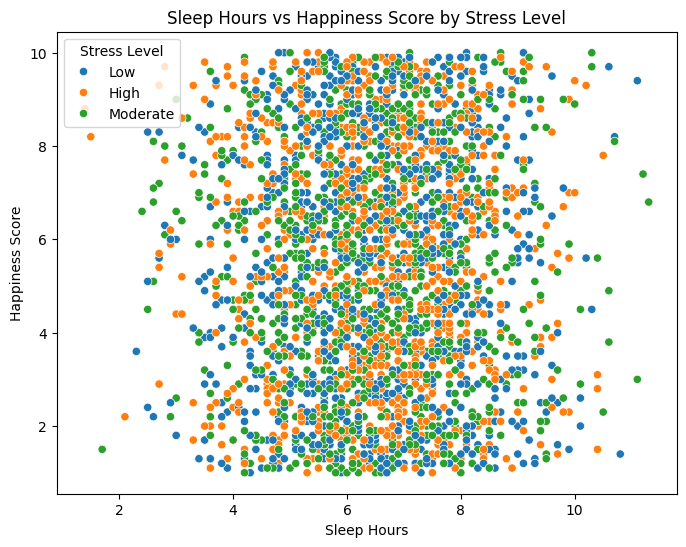

In [33]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Sleep Hours',
    y='Happiness Score',
    hue='Stress Level'
)

plt.title('Sleep Hours vs Happiness Score by Stress Level')
plt.xlabel('Sleep Hours')
plt.ylabel('Happiness Score')
plt.show()

Scatter Plot Findings

The scatter plot shows substantial overlap among the Low, Moderate, and High Stress Level classes. There is no clear separation between the classes based on Sleep Hours and Happiness Score, and no strong relationship between these two attributes is visually apparent. This suggests that these two attributes alone may not be sufficient to distinguish between the Stress Level classes. The plot does not indicate a specific preprocessing issue for these two attributes.






# **4**. **Data** **Preprocessing**

Data preprocessing is applied to prepare the dataset for data mining techniques. the identified missing values and potential outliers are treated while preserving the original dataset. A separate copy of the dataset is used for preprocessing.

## 4.1 Creating a Copy of the Dataset

A copy of the original dataset was created before applying any preprocessing techniques. This ensures that the original dataset remains unchanged.

In [34]:
processed_df = df.copy()

print("Original dataset shape:", df.shape)
print("Processed dataset shape:", processed_df.shape)

Original dataset shape: (3000, 12)
Processed dataset shape: (3000, 12)


##4.2 Handling Missing Values

The missing value analysis showed that the "Mental Health Condition" attribute contains 595 missing values.

Since "Mental Health Condition" is a categorical attribute, the mode was used to replace the missing values. The mode is "Anxiety", which is the most frequent category in the dataset.

In [35]:
mode_value = processed_df["Mental Health Condition"].mode()[0]

processed_df["Mental Health Condition"] = processed_df[
    "Mental Health Condition"
].fillna(mode_value)

print("Mode used:", mode_value)
print("Missing values after treatment:",
      processed_df["Mental Health Condition"].isnull().sum())

Mode used: Anxiety
Missing values after treatment: 0


### Missing Values Findings

The 595 missing values in "Mental Health Condition" were replaced using mode imputation. The mode was "Anxiety". After the treatment, no missing values remained in this attribute, and all 3,000 records were retained.

##4.3 Outlier Detection and Treatment

During the Data Analysis phase, the IQR method identified potential outliers in the "Sleep Hours" attribute.

The IQR method was used to calculate the lower and upper bounds. Instead of removing the outlier records, IQR capping was applied to reduce the effect of extreme values while preserving all observations.

In [36]:
Q1 = processed_df["Sleep Hours"].quantile(0.25)
Q3 = processed_df["Sleep Hours"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 5.5
Q3: 7.5
IQR: 2.0
Lower Bound: 2.5
Upper Bound: 10.5


In [37]:
outliers_before = (
    (processed_df["Sleep Hours"] < lower_bound) |
    (processed_df["Sleep Hours"] > upper_bound)
).sum()

print("Potential outliers before treatment:", outliers_before)

processed_df["Sleep Hours"] = processed_df["Sleep Hours"].clip(
    lower=lower_bound,
    upper=upper_bound
)

print("Minimum after treatment:",
      processed_df["Sleep Hours"].min())

print("Maximum after treatment:",
      processed_df["Sleep Hours"].max())

Potential outliers before treatment: 16
Minimum after treatment: 2.5
Maximum after treatment: 10.5


### Boxplot After Outlier Treatment

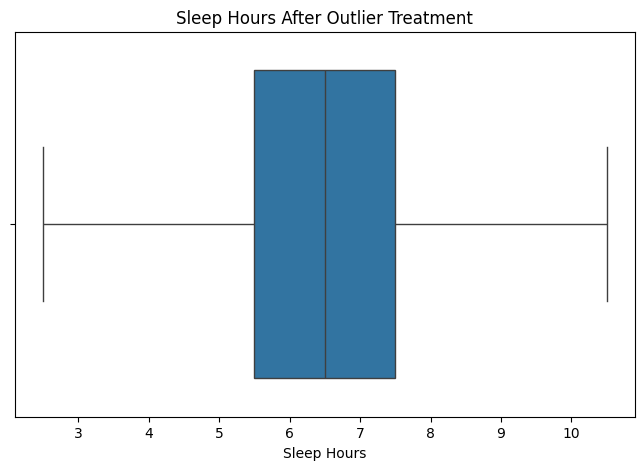

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=processed_df["Sleep Hours"])

plt.title("Sleep Hours After Outlier Treatment")
plt.xlabel("Sleep Hours")

plt.show()

### Outlier Treatment Findings

The IQR method identified 16 potential outliers in "Sleep Hours". The calculated lower and upper bounds were 2.5 and 10.5 hours, respectively.

IQR capping was applied to "Sleep Hours". Values below 2.5 were replaced with 2.5, while values above 10.5 were replaced with 10.5. This treatment preserved all 3,000 records while reducing the effect of extreme values.

##4.4 Data Normalization


Data normalization is a preprocessing technique used to scale numerical attributes to a common range. It helps make the values comparable and prevents attributes with larger numerical ranges from having a greater influence on the analysis.

In [39]:
from sklearn.preprocessing import MinMaxScaler
columns_to_normalize=['Age',
                      'Sleep Hours',
                      'Work Hours per Week',
                      'Screen Time per Day (Hours)',
                      'Social Interaction Score',
                      'Happiness Score']
scaler=MinMaxScaler()

processed_df[columns_to_normalize]=scaler.fit_transform(processed_df[columns_to_normalize])
processed_df[columns_to_normalize].head()

,Age,Sleep Hours,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,0.652174,0.4750,0.025641,0.333333,0.755556,0.611111
1,0.282609,0.3000,0.717949,0.533333,0.800000,0.644444
2,0.413043,0.5875,0.589744,0.450000,0.955556,0.966667
3,0.369565,0.5875,0.589744,0.033333,0.800000,0.622222
4,0.608696,0.6000,0.384615,0.266667,0.411111,0.377778


The Min-Max Scaling technique transformed all selected numerical attributes into a common range between 0 and 1. The normalized values show that the original differences in measurement scales were reduced. For example, the Age values were transformed into values between 0 and 1, and the same transformation was applied to Sleep Hours, Work Hours per Week, Screen Time per Day, Social Interaction Score, and Happiness Score. This makes the numerical attributes comparable and reduces the influence of attributes with larger original scales.

##4.5 Preprocessed Dataset Snapshot

The following table shows a sample of the dataset after applying the preprocessing techniques.

In [40]:
display(processed_df.head())

,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,0.652174,Male,Low,Vegetarian,0.4750,Low,Anxiety,0.025641,0.333333,0.755556,0.611111
1,Australia,0.282609,Male,Moderate,Vegan,0.3000,Low,PTSD,0.717949,0.533333,0.800000,0.644444
2,Japan,0.413043,Female,Low,Vegetarian,0.5875,High,Anxiety,0.589744,0.450000,0.955556,0.966667
3,Brazil,0.369565,Male,Low,Vegan,0.5875,Low,Depression,0.589744,0.033333,0.800000,0.622222
4,Germany,0.608696,Male,Low,Balanced,0.6000,Low,Anxiety,0.384615,0.266667,0.411111,0.377778


## 4.6 Saving The Preprocessed Dataset

The processed dataset was saved as a separate CSV file named Preprocessed_dataset.csv.

In [41]:
processed_df.to_csv("Preprocessed_dataset.csv", index=False)

The file contains the data after applying the preprocessing techniques.